# STORM — Spatial-motif model training (GATv2 variational graph autoencoder)

This notebook is the **core model** of STORM (Spatial Topology analysis of Recurrent
Motifs). It learns a per-cell *niche embedding* from single-cell spatial
transcriptomics with a GATv2-based **variational graph autoencoder (VGAE)**, then
clusters those embeddings into recurrent **spatial motifs** with MiniBatch
*k*-means.

**Pipeline**
1. Read per-sample `.h5ad`, QC + normalize + scale, align to a shared gene panel.
2. Build a per-sample k-nearest-neighbour spatial graph (edges weighted by
   inverse intercellular distance).
3. Train a GATv2 VGAE with spatial-patch sampling (joint feature- and
   structure-reconstruction + KL regularization).
4. Encode every cell to a 20-D niche embedding and cluster into motifs.
5. Export embeddings, motif labels, attention weights, and a motif map.

> **Reviewer note.** This runs on the small **synthetic** cohort in
> `data/example/`. It has no absolute paths and runs on CPU or GPU. Hyper-parameters here are scaled
> down for a quick demo; values used in the paper are noted in `Config`.

In [1]:
import os, re, glob, warnings, contextlib
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from torch_geometric.utils import subgraph, k_hop_subgraph
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans

sc.settings.verbosity = 0
warnings.filterwarnings("ignore")

# Resolve paths relative to the repo root, whether Jupyter is launched from the
# repo root or from inside notebooks/.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.path.basename(os.getcwd()) + "/")

Working directory: STORM4review/


## 1. Configuration

All paths are **relative to the repository root**. On HPC clusters a torch/MKL
OpenMP clash sometimes requires `LD_PRELOAD=<env>/lib/libiomp5.so`; set it in the
shell before launching Jupyter if you hit an `iJIT_NotifyEvent` import error.

In [2]:
class Config:
    # --- Paths (relative to repo root) ---
    DATA_DIR = "data/example"
    OUT_DIR = "outputs"
    PROCESSED_GRAPH_FILE = "outputs/processed_graphs.pt"
    MODEL_SAVE_PATH = "outputs/storm_gat_vgae.pth"
    RESULT_CSV = "outputs/spatial_motifs_results.csv"
    EMBEDDING_FILE = "outputs/cell_niche_embeddings.npy"
    PLOT_FILE = "outputs/motif_spatial_map.png"

    # --- Attention export (for the mechanism figure, notebook 03) ---
    EXPORT_ATTENTION = True
    ATTENTION_SAMPLE_LIMIT = 5

    # --- Preprocessing ---
    K_NEIGHBORS = 10
    MIN_COUNTS_PER_CELL = 10
    TARGET_SUM = 1e4
    SCALE_MAX = 10

    # --- Model architecture (GATv2 + VGAE) ---
    LATENT_DIM = 20
    HIDDEN_DIM = 64
    GAT_HEADS = 4
    DROPOUT = 0.2

    # --- Training ---  (paper: EPOCHS=100, PATCH_SIZE=4096, STEPS_PER_EPOCH=50)
    EPOCHS = 30
    LEARNING_RATE = 5e-4
    PATCH_SIZE = 1024
    STEPS_PER_EPOCH = 20
    KL_WEIGHT = 0.005

    # --- Inference / clustering ---  (paper: N_MOTIFS=10)
    N_MOTIFS = 8
    CHUNK_SIZE = 8192

    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(Config.OUT_DIR, exist_ok=True)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)

USE_AMP = Config.DEVICE.type == "cuda"   # mixed precision only helps on GPU
autocast_ctx = (lambda: torch.amp.autocast("cuda")) if USE_AMP else contextlib.nullcontext
print(f"Running on {Config.DEVICE} (mixed precision: {USE_AMP})")

Running on cuda (mixed precision: True)


## 2. Data processing

Each sample becomes one spatial graph: nodes are cells (scaled gene expression as
features), edges connect each cell to its `K_NEIGHBORS` nearest spatial
neighbours, weighted by inverse physical distance. Condition (CA/NL) and patient
id are parsed from the filename.

In [3]:
def extract_metadata_from_filename(fn):
    """Recover (condition, patient) from a Xenium-style filename token."""
    m = re.search(r"(CA|NL)(\d+)", fn)
    return (m.group(1), m.group(2)) if m else (None, None)

def get_master_gene_list(data_dir):
    """Union of genes across all samples (handles jagged panels)."""
    genes = set()
    for f in sorted(glob.glob(os.path.join(data_dir, "*.h5ad"))):
        genes.update(sc.read_h5ad(f).var_names)
    return sorted(genes)

def align_adata_features(adata, master):
    """Pad missing genes with zeros so every sample shares one feature space."""
    missing = list(set(master) - set(adata.var_names))
    if missing:
        df = adata.to_df()
        df = pd.concat([df, pd.DataFrame(0.0, index=df.index, columns=missing)], axis=1)[master]
        new = sc.AnnData(X=df.values, obs=adata.obs)
        new.var_names = master
        for col in ["x_centroid", "y_centroid"]:
            if col in adata.obs:
                new.obs[col] = adata.obs[col]
        return new
    return adata[:, master].copy() if list(adata.var_names) != master else adata

def preprocess_and_align(adata, master):
    """QC filter, library-size normalize, log1p, z-scale, align to master panel."""
    sc.pp.filter_cells(adata, min_counts=Config.MIN_COUNTS_PER_CELL)
    adata = align_adata_features(adata, master)
    if adata.n_obs < 100:
        return None
    sc.pp.normalize_total(adata, target_sum=Config.TARGET_SUM)
    sc.pp.log1p(adata)
    sc.pp.scale(adata, max_value=Config.SCALE_MAX)
    return adata

def build_graph(adata, sample_id, condition, patient):
    """kNN spatial graph with inverse-distance edge weights."""
    x = torch.tensor(np.asarray(adata.X), dtype=torch.float)
    coords = adata.obs[["x_centroid", "y_centroid"]].values
    pos = torch.tensor(coords, dtype=torch.float)

    nbrs = NearestNeighbors(n_neighbors=Config.K_NEIGHBORS + 1).fit(coords)
    dist, idx = nbrs.kneighbors(coords)
    src = np.repeat(np.arange(coords.shape[0]), Config.K_NEIGHBORS)
    dst = idx[:, 1:].flatten()                     # drop self at column 0
    edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)
    edge_attr = torch.tensor(1.0 / (dist[:, 1:].flatten() + 1.0),
                             dtype=torch.float).view(-1, 1)

    d = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, pos=pos)
    d.sample_id = sample_id
    d.is_cancer = torch.tensor([1 if condition == "CA" else 0])
    d.patient_id = torch.tensor([int(patient) if patient.isdigit() else -1])
    return d

def run_preprocessing_pipeline():
    if os.path.exists(Config.PROCESSED_GRAPH_FILE):
        print(f"Loading cached graphs from {Config.PROCESSED_GRAPH_FILE}")
        return torch.load(Config.PROCESSED_GRAPH_FILE, weights_only=False)
    master = get_master_gene_list(Config.DATA_DIR)
    print(f"Master gene panel: {len(master)} genes")
    dataset = []
    for f in tqdm(sorted(glob.glob(os.path.join(Config.DATA_DIR, "*.h5ad"))),
                  desc="Preprocessing"):
        cond, pid = extract_metadata_from_filename(os.path.basename(f))
        if not cond:
            continue
        adata = preprocess_and_align(sc.read_h5ad(f), master)
        if adata is not None:
            d = build_graph(adata, os.path.basename(f), cond, pid)
            if d is not None:
                dataset.append(d)
    torch.save(dataset, Config.PROCESSED_GRAPH_FILE)
    print(f"Saved {len(dataset)} graphs")
    return dataset

dataset = run_preprocessing_pipeline()
print(f"{len(dataset)} graphs | {dataset[0].x.shape[1]} features | "
      f"{sum(d.num_nodes for d in dataset)} cells total")

Master gene panel: 60 genes


Preprocessing:   0%|          | 0/6 [00:00<?, ?it/s]

Preprocessing:  17%|█▋        | 1/6 [00:01<00:07,  1.54s/it]

Preprocessing: 100%|██████████| 6/6 [00:01<00:00,  4.83it/s]

Preprocessing: 100%|██████████| 6/6 [00:01<00:00,  3.65it/s]

Saved 6 graphs
6 graphs | 60 features | 7200 cells total


## 3. Model — GATv2 variational graph autoencoder

A two-layer GATv2 encoder produces variational parameters of a 20-D latent niche
embedding. Two decoders reconstruct (a) the cell feature vector and (b) the local
graph structure (inner-product edge decoder), with a KL term keeping the latent
space smooth. Edge weights (inverse distance) enter attention via `edge_dim=1`.

In [4]:
class SpatialMotifVGAE(nn.Module):
    def __init__(self, in_channels, hidden_channels, latent_channels, heads=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.enc1 = GATv2Conv(in_channels, hidden_channels, heads=heads, concat=True,
                              dropout=dropout, edge_dim=1, add_self_loops=False)
        hc = hidden_channels * heads
        self.conv_mu = GATv2Conv(hc, latent_channels, heads=1, concat=False,
                                 dropout=dropout, edge_dim=1, add_self_loops=False)
        self.conv_logstd = GATv2Conv(hc, latent_channels, heads=1, concat=False,
                                     dropout=dropout, edge_dim=1, add_self_loops=False)
        self.decoder = nn.Sequential(
            nn.Linear(latent_channels, hidden_channels), nn.ReLU(),
            nn.Linear(hidden_channels, in_channels))

    def reparameterize(self, mu, logstd):
        if self.training:
            return mu + torch.randn_like(logstd) * torch.exp(logstd)
        return mu

    def encode(self, x, edge_index, edge_attr, return_attention=False):
        if return_attention:
            h1, (ei, alpha) = self.enc1(x, edge_index, edge_attr=edge_attr,
                                        return_attention_weights=True)
        else:
            h1 = self.enc1(x, edge_index, edge_attr=edge_attr)
            ei, alpha = None, None
        h1 = F.dropout(F.elu(h1), p=self.dropout, training=self.training)
        mu = self.conv_mu(h1, edge_index, edge_attr=edge_attr)
        logstd = torch.clamp(self.conv_logstd(h1, edge_index, edge_attr=edge_attr), -6, 2)
        return mu, logstd, ei, alpha

    def decode_structure(self, z, edge_index, apply_sigmoid=True):
        src, dst = edge_index
        logits = torch.clamp((z[src] * z[dst]).sum(dim=1), -10, 10)
        return torch.sigmoid(logits) if apply_sigmoid else logits

    def decode_feature(self, z):
        return self.decoder(z)

    def forward(self, x, edge_index, edge_attr):
        mu, logstd, _, _ = self.encode(x, edge_index, edge_attr)
        z = self.reparameterize(mu, logstd)
        return z, self.decode_feature(z), mu, logstd

## 4. Training — spatial-patch sampling

Each step samples a spatial patch (the `PATCH_SIZE` cells nearest a random centre)
to bound memory, and optimizes a weighted sum of feature-reconstruction (MSE),
structure-reconstruction (BCE with negative edge sampling) and KL. Gradient
clipping + logstd/logit clamps keep training stable; mixed precision is used on
GPU only.

In [5]:
def train_model(dataset):
    in_dim = dataset[0].x.shape[1]
    model = SpatialMotifVGAE(in_dim, Config.HIDDEN_DIM, Config.LATENT_DIM,
                             heads=Config.GAT_HEADS, dropout=Config.DROPOUT).to(Config.DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    model.train()
    history = []
    for epoch in range(1, Config.EPOCHS + 1):
        running = {"loss": 0, "recon": 0, "struct": 0, "kl": 0}
        for _ in range(Config.STEPS_PER_EPOCH):
            data = dataset[np.random.randint(len(dataset))]
            center = np.random.randint(data.num_nodes)
            dists = torch.sum((data.pos - data.pos[center]) ** 2, dim=1)
            k = min(Config.PATCH_SIZE, data.num_nodes)
            _, subset = torch.topk(dists, k, largest=False)
            ei, ea = subgraph(subset, data.edge_index, edge_attr=data.edge_attr,
                              relabel_nodes=True, num_nodes=data.num_nodes)
            x = data.x[subset].to(Config.DEVICE)
            ei, ea = ei.to(Config.DEVICE), ea.to(Config.DEVICE)

            opt.zero_grad()
            with autocast_ctx():
                z, x_hat, mu, logstd = model(x, ei, ea)
                loss_recon = F.mse_loss(x_hat, x)
                pos_logits = model.decode_structure(z, ei, apply_sigmoid=False)
                neg_ei = torch.randint(0, x.size(0), ei.size(), device=Config.DEVICE)
                neg_logits = model.decode_structure(z, neg_ei, apply_sigmoid=False)
                logits = torch.cat([pos_logits, neg_logits])
                labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
                loss_struct = F.binary_cross_entropy_with_logits(logits, labels)
                kl = -0.5 * torch.mean(torch.sum(1 + 2 * logstd - mu.pow(2) - (2 * logstd).exp(), dim=1))
                loss = 10 * loss_recon + loss_struct + Config.KL_WEIGHT * kl

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()

            running["loss"] += loss.item();   running["recon"] += loss_recon.item()
            running["struct"] += loss_struct.item(); running["kl"] += kl.item()
        for kk in running:
            running[kk] /= Config.STEPS_PER_EPOCH
        history.append(running)
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | loss {running['loss']:.3f} "
                  f"(recon {running['recon']:.3f}, struct {running['struct']:.3f}, kl {running['kl']:.3f})")
    torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
    print(f"Saved model -> {Config.MODEL_SAVE_PATH}")
    return model, pd.DataFrame(history)

model, history = train_model(dataset)

Epoch 001 | loss 11.786 (recon 1.035, struct 1.419, kl 3.719)


Epoch 005 | loss 9.884 (recon 0.911, struct 0.652, kl 24.237)


Epoch 010 | loss 8.810 (recon 0.788, struct 0.775, kl 30.365)


Epoch 015 | loss 8.328 (recon 0.747, struct 0.688, kl 34.656)


Epoch 020 | loss 8.034 (recon 0.720, struct 0.645, kl 38.128)


Epoch 025 | loss 7.929 (recon 0.711, struct 0.617, kl 39.842)


Epoch 030 | loss 7.889 (recon 0.708, struct 0.602, kl 40.688)
Saved model -> outputs/storm_gat_vgae.pth


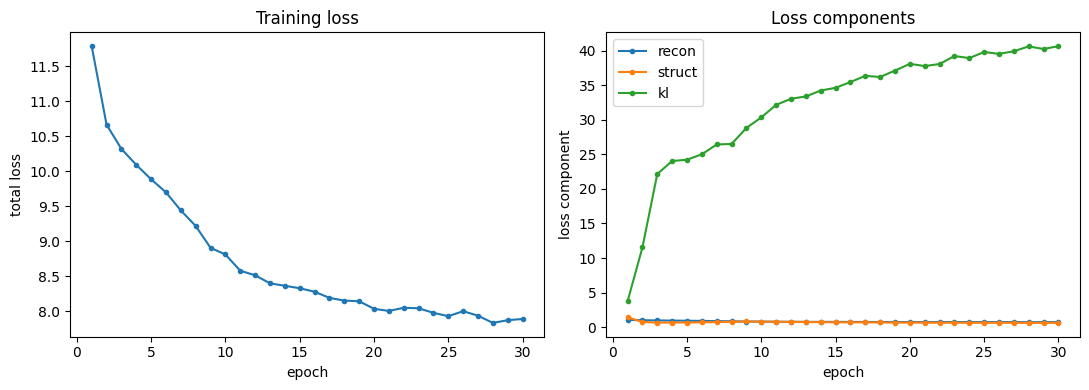

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history.index + 1, history["loss"], "-o", ms=3)
ax[0].set(xlabel="epoch", ylabel="total loss", title="Training loss")
for comp in ["recon", "struct", "kl"]:
    ax[1].plot(history.index + 1, history[comp], "-o", ms=3, label=comp)
ax[1].set(xlabel="epoch", ylabel="loss component", title="Loss components")
ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(Config.OUT_DIR, "training_loss.png"), dpi=150)
plt.show()

## 5. Inference — niche embeddings, motifs, attention export

Cells are encoded in 2-hop tiles (memory-bounded), the posterior mean `mu` is the
niche embedding, and MiniBatch *k*-means clusters all embeddings into motifs. We
also dump per-edge attention for the first few samples (used in notebook 03).

In [7]:
def run_inference(dataset, model):
    model.eval()
    embeddings, meta_rows, saved = [], [], 0
    for data in tqdm(dataset, desc="Inference"):
        N = data.num_nodes
        emb = np.zeros((N, Config.LATENT_DIM), dtype=np.float32)
        save_attn = Config.EXPORT_ATTENTION and saved < Config.ATTENTION_SAMPLE_LIMIT
        for s in range(0, N, Config.CHUNK_SIZE):
            e = min(s + Config.CHUNK_SIZE, N)
            node_idx = torch.arange(s, e)
            subset, ei, mapping, _ = k_hop_subgraph(node_idx, 2, data.edge_index, relabel_nodes=True)
            x = data.x[subset].to(Config.DEVICE)
            ei = ei.to(Config.DEVICE)
            pos = data.pos[subset].to(Config.DEVICE)
            src, dst = ei
            dist = (pos[src] - pos[dst]).pow(2).sum(dim=1).sqrt()
            ea = (1.0 / (dist + 1.0)).view(-1, 1)
            with torch.no_grad(), autocast_ctx():
                mu, _, ei_attn, alpha = model.encode(x, ei, ea, return_attention=save_attn)
            emb[s:e] = mu[mapping].float().cpu().numpy()
            if save_attn and s == 0:
                np.savez(os.path.join(Config.OUT_DIR, f"attention_{data.sample_id}.npz"),
                         edge_index=ei_attn.cpu().numpy(),
                         attn=alpha.mean(dim=1).cpu().numpy(),
                         pos=pos.cpu().numpy())
        if save_attn:
            saved += 1
        embeddings.append(emb)
        coords = data.pos.numpy()
        meta_rows.append(pd.DataFrame({
            "Sample": data.sample_id, "x": coords[:, 0], "y": coords[:, 1],
            "Condition": "Cancer" if data.is_cancer.item() else "Normal",
            "Patient": int(data.patient_id.item())}))

    all_emb = np.vstack(embeddings)
    meta = pd.concat(meta_rows, ignore_index=True)
    np.save(Config.EMBEDDING_FILE, all_emb)
    km = MiniBatchKMeans(n_clusters=Config.N_MOTIFS, batch_size=4096,
                         n_init="auto", random_state=Config.SEED)
    meta["Spatial_Motif"] = km.fit_predict(all_emb)
    meta.to_csv(Config.RESULT_CSV, index=False)
    print(f"Embeddings {all_emb.shape} -> {Config.EMBEDDING_FILE}")
    print(f"Motif table {meta.shape} -> {Config.RESULT_CSV}")
    return meta, all_emb

motifs, embeddings = run_inference(dataset, model)
motifs["Spatial_Motif"].value_counts().sort_index()

Inference:   0%|          | 0/6 [00:00<?, ?it/s]

Inference: 100%|██████████| 6/6 [00:00<00:00, 58.27it/s]

Inference: 100%|██████████| 6/6 [00:00<00:00, 57.65it/s]

Embeddings (7200, 20) -> outputs/cell_niche_embeddings.npy
Motif table (7200, 6) -> outputs/spatial_motifs_results.csv


Spatial_Motif
0     649
1    1212
2     789
3     846
4     857
5    1231
6     843
7     773
Name: count, dtype: int64

## 6. Visualization — spatial motif maps

Plot the recovered motifs in physical space per sample. With the synthetic cohort
you should see motifs that organize into coherent territories (tumour core,
barrier, immune-rich periphery in CA; crypt/stroma in NL).

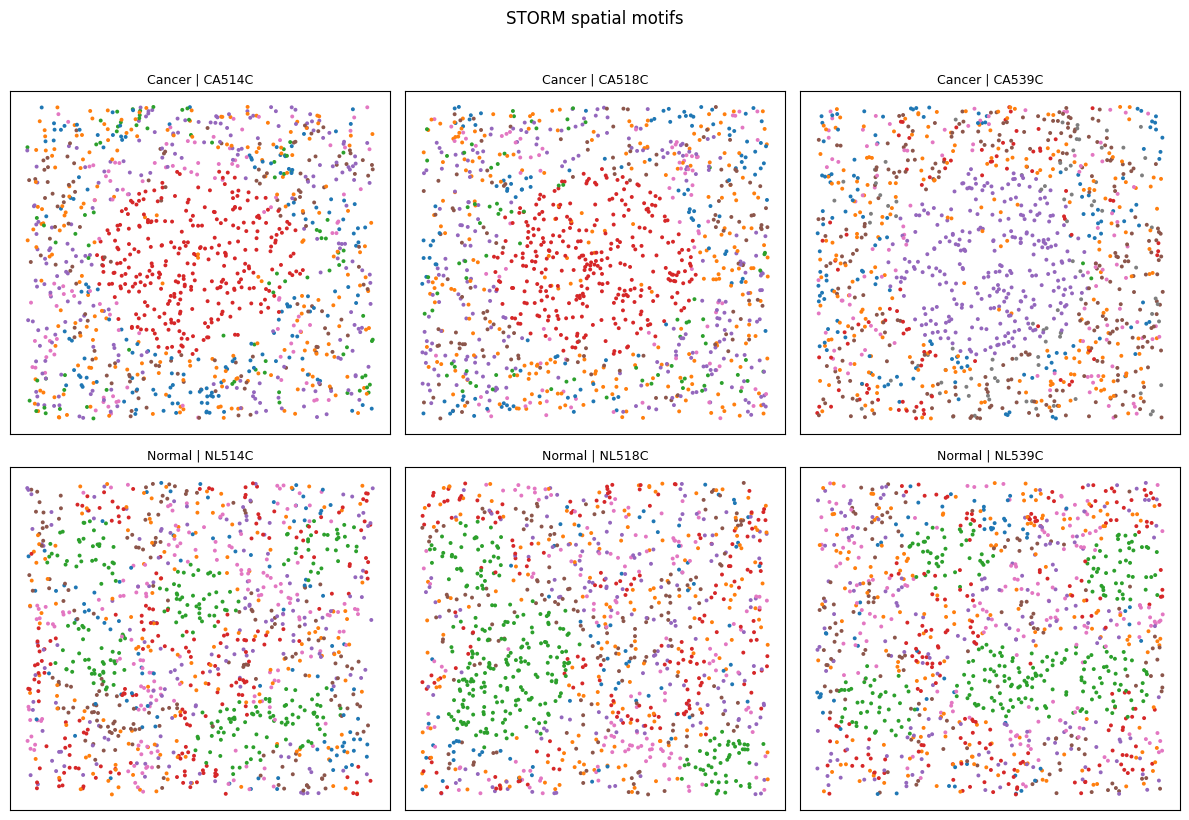

Saved outputs/motif_spatial_map.png


In [8]:
samples = motifs["Sample"].unique()
ncol = 3
nrow = int(np.ceil(len(samples) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow))
for ax, s in zip(np.atleast_1d(axes).ravel(), samples):
    sub = motifs[motifs["Sample"] == s]
    sns.scatterplot(data=sub, x="x", y="y", hue="Spatial_Motif", palette="tab10",
                    s=8, linewidth=0, ax=ax, legend=False)
    ax.set_title(sub["Condition"].iloc[0] + " | " + s.replace("sample_", "").replace(".h5ad", ""),
                 fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(""); ax.set_ylabel("")
for ax in np.atleast_1d(axes).ravel()[len(samples):]:
    ax.axis("off")
plt.suptitle("STORM spatial motifs", y=1.02)
plt.tight_layout()
plt.savefig(Config.PLOT_FILE, dpi=150, bbox_inches="tight")
plt.show()
print("Saved", Config.PLOT_FILE)

**Outputs written to `outputs/`**

| file | contents |
|---|---|
| `cell_niche_embeddings.npy` | per-cell 20-D niche embedding |
| `spatial_motifs_results.csv` | per-cell motif label + coords + condition/patient |
| `storm_gat_vgae.pth` | trained model weights |
| `attention_*.npz` | per-edge attention for the mechanism figure |
| `motif_spatial_map.png`, `training_loss.png` | figures |

Continue with **`02_motif_characterization.ipynb`** (what the motifs are).